In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score,cross_validate
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,f1_score,recall_score,precision_score,accuracy_score


In [2]:
dir = os.getcwd()
credit_card_df = pd.read_csv('../data/creditcard.csv')

duplicate_values = credit_card_df.duplicated()

credit_card_df = credit_card_df.drop_duplicates()

In [3]:
X = credit_card_df.drop('Class' ,axis =1)
y = credit_card_df['Class']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

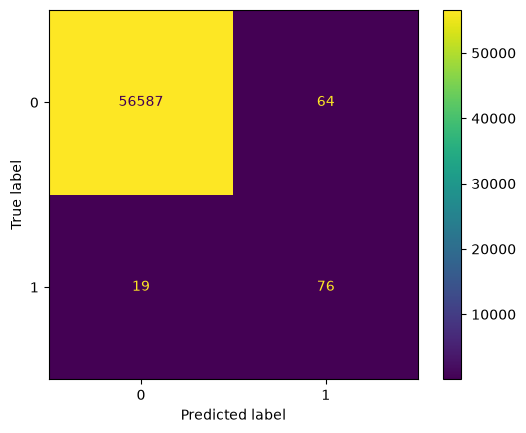

In [4]:
random_forest_model = RandomForestClassifier(max_depth=7,class_weight='balanced')
random_forest_model.fit(X_train,y_train)
y_pred_random_forest= random_forest_model.predict(X_test)
confution_matrix_random_forest = confusion_matrix(y_test,y_pred_random_forest)
ConfusionMatrixDisplay(confution_matrix_random_forest).plot()

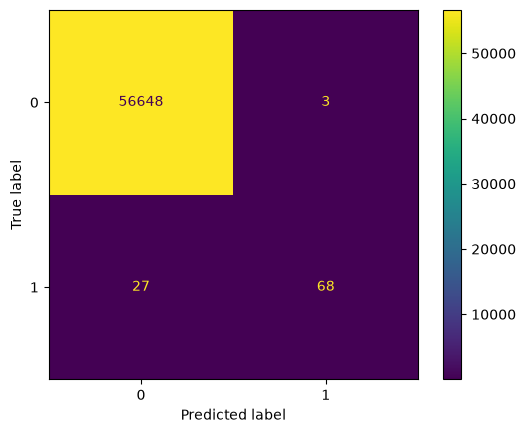

In [5]:
random_forest_model = RandomForestClassifier(max_depth=7)
random_forest_model.fit(X_train,y_train)
y_pred_random_forest= random_forest_model.predict(X_test)
y_pred_t_random_forest = random_forest_model.predict(X_train)

confution_matrix_random_forest = confusion_matrix(y_test,y_pred_random_forest)
ConfusionMatrixDisplay(confution_matrix_random_forest).plot()